## Desempenho Colab x Pc local

Antes de mostrar os resultados, é importante entender que a ideia do projeto foi comparar o desempenho da execução dos algoritmos de equalização de sinais ópticos, tanto na CPU quanto na GPU.

A CPU é o processador tradicional, que executa as tarefas de forma sequencial ou com poucos núcleos, enquanto a GPU é projetada para trabalhar com milhares de núcleos em paralelo, o que em teoria permite acelerar cálculos matemáticos pesados, como os usados nesses algoritmos de comunicações ópticas.

Então, o que nós fizemos foi medir o tempo de execução dos principais algoritmos de equalização, o CMA e o RDE, que fazem a equalização cega do sinal, e o DD-LMS, que é o equalizador adaptativo, executando em dois ambientes: um PC local com uma GPU RTX, e o Google Colab, que usa uma GPU Tesla T4.
Em cada caso, nós testamos tanto o processamento com CPU (NumPy) quanto com GPU (CuPy).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ================================================================
#       Carregamento dos resultados dos setups (PC e Colab)
# ================================================================

data_pc = np.load("tempo_execucao_PC.npz")
data_colab = np.load("tempo_execucao_colab.npz")

numberOfSymbols = data_pc["numberOfSymbols"]

####################### PC local #######################
timeEqCPU_pc = data_pc["timeEqCPU"]
timeEqGPU_pc = data_pc["timeEqGPU"]
timeEqAdCPU_pc = data_pc["timeEqAdCPU"]
timeEqAdGPU_pc = data_pc["timeEqAdGPU"]

##################### Google Colab #####################
timeEqCPU_colab = data_colab["timeEqCPU"]
timeEqGPU_colab = data_colab["timeEqGPU"]
timeEqAdCPU_colab = data_colab["timeEqAdCPU"]
timeEqAdGPU_colab = data_colab["timeEqAdGPU"]

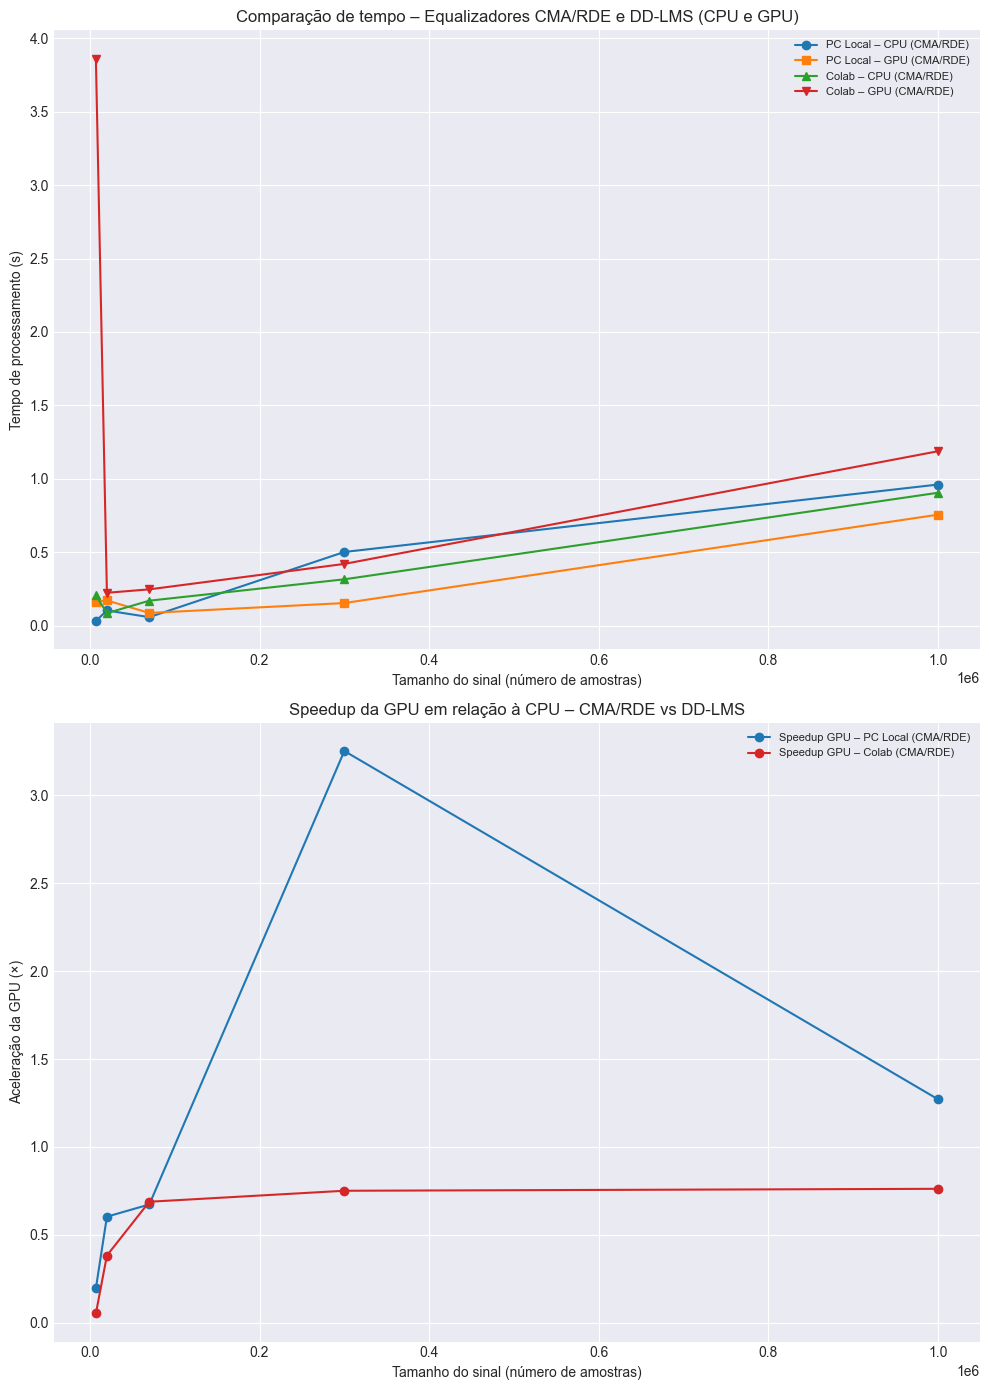

In [12]:
# ================================================================
#           COMPARAÇÃO GERAL – CMA/RDE (CPU e GPU)
# ================================================================

fig, axis = plt.subplots(2, 1, figsize=(10, 14))
plt.style.use("seaborn-v0_8-darkgrid")

####################### CMA/RDE #######################
axis[0].plot(numberOfSymbols, timeEqCPU_pc, '-o', color='tab:blue', label='PC Local – CPU (CMA/RDE)')
axis[0].plot(numberOfSymbols, timeEqGPU_pc, '-s', color='tab:orange', label='PC Local – GPU (CMA/RDE)')
axis[0].plot(numberOfSymbols, timeEqCPU_colab, '-^', color='tab:green', label='Colab – CPU (CMA/RDE)')
axis[0].plot(numberOfSymbols, timeEqGPU_colab, '-v', color='tab:red', label='Colab – GPU (CMA/RDE)')

axis[0].set_xlabel('Tamanho do sinal (número de amostras)')
axis[0].set_ylabel('Tempo de processamento (s)')
axis[0].set_title('Comparação de tempo – Equalizadores CMA/RDE e DD-LMS (CPU e GPU)')
axis[0].legend(loc='best', fontsize=8)
axis[0].grid(True)

# ================================================================
#           SPEEDUP: CMA/RDE (PC e Colab)
# ================================================================

axis[1].plot(numberOfSymbols, timeEqCPU_pc/timeEqGPU_pc, '-o', color='tab:blue', label='Speedup GPU – PC Local (CMA/RDE)')
axis[1].plot(numberOfSymbols, timeEqCPU_colab/timeEqGPU_colab, '-o', color='tab:red', label='Speedup GPU – Colab (CMA/RDE)')

axis[1].set_xlabel('Tamanho do sinal (número de amostras)')
axis[1].set_ylabel('Aceleração da GPU (×)')
axis[1].set_title('Speedup da GPU em relação à CPU – CMA/RDE vs DD-LMS')
axis[1].legend(loc='best', fontsize=8)
axis[1].grid(True)

plt.tight_layout()
plt.show()


### Analise - CMA/RDE (Equalização Cega)

No gráfico superior, observamos o tempo de processamento dos algoritmos CMA e RDE.

Para sinais pequenos (até 20 mil amostras), a CPU é mais eficiente. Isso acontece porque a GPU precisa inicializar o ambiente CUDA e transferir os dados da memória principal — esse custo é alto quando o sinal é curto. À medida que o tamanho do sinal cresce, a GPU começa a compensar esse custo, aproveitando o paralelismo de milhares de núcleos.

No PC local, o ganho é mais evidente, pois a RTX 3060 tem mais núcleos CUDA e uma banda de memória mais alta. Já no Colab, os tempos são maiores e a diferença entre CPU e GPU é menor, por conta da limitação da GPU Tesla T4 e do ambiente virtualizado.

No gráfico inferior, temos o speedup (razão entre CPU e GPU). No PC local, a GPU chega a ser 3 vezes mais rápida para sinais grandes (~1 milhão de amostras), mostrando o potencial da paralelização. Já no Colab, o ganho fica entre 1,2× e 1,5×, o que é esperado dado o hardware

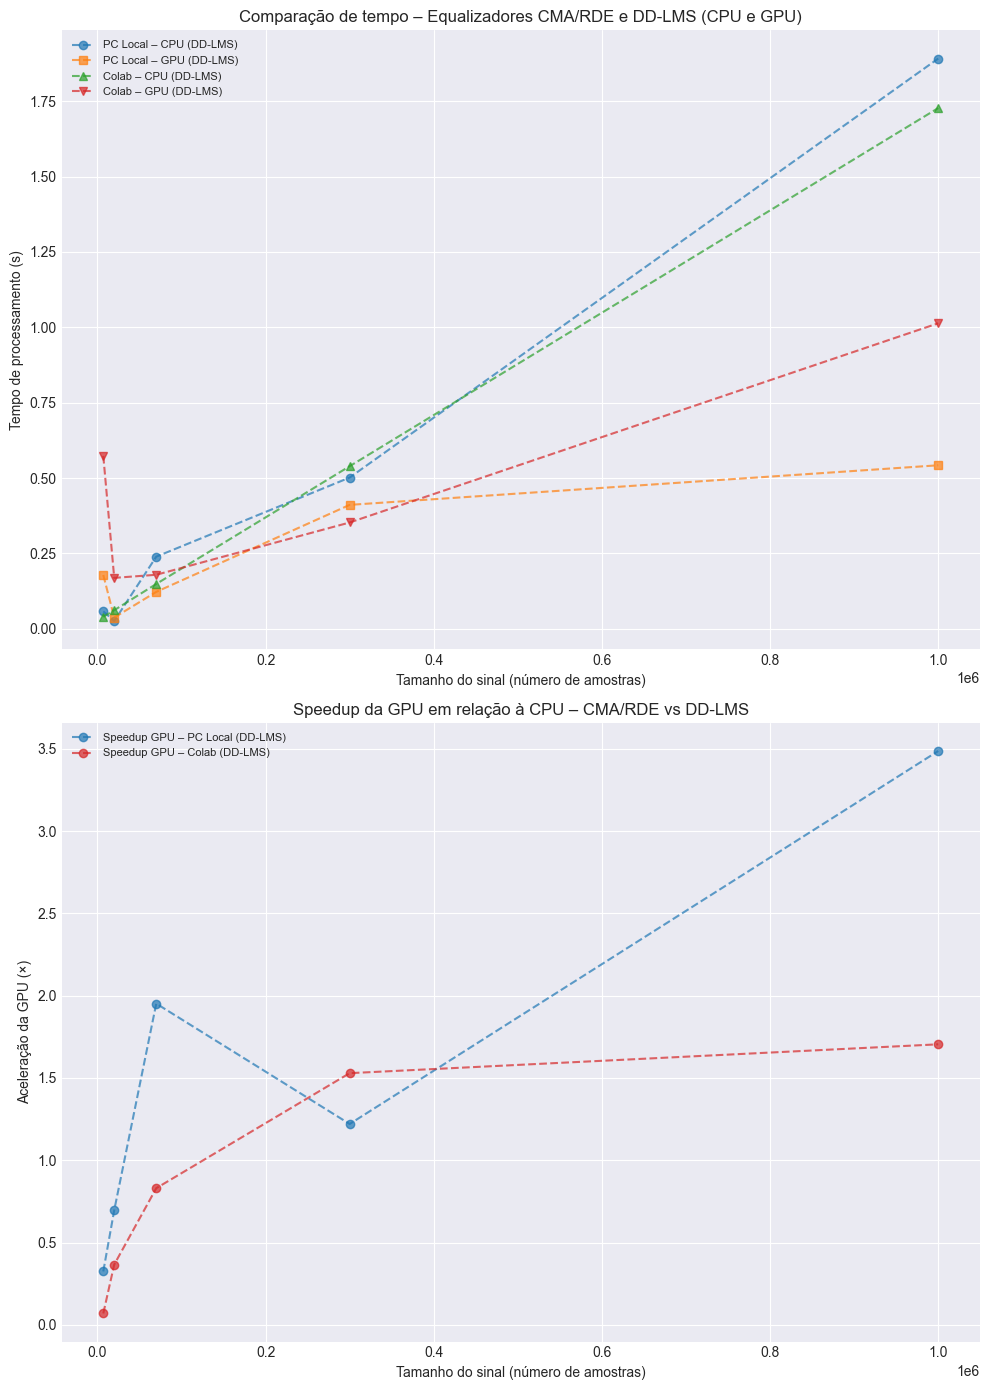

In [11]:
# ================================================================
#           COMPARAÇÃO GERAL – DD-LMS (CPU e GPU)
# ================================================================

fig, axis = plt.subplots(2, 1, figsize=(10, 14))
plt.style.use("seaborn-v0_8-darkgrid")

axis[0].plot(numberOfSymbols, timeEqAdCPU_pc, '--o', color='tab:blue', alpha=0.7, label='PC Local – CPU (DD-LMS)')
axis[0].plot(numberOfSymbols, timeEqAdGPU_pc, '--s', color='tab:orange', alpha=0.7, label='PC Local – GPU (DD-LMS)')
axis[0].plot(numberOfSymbols, timeEqAdCPU_colab, '--^', color='tab:green', alpha=0.7, label='Colab – CPU (DD-LMS)')
axis[0].plot(numberOfSymbols, timeEqAdGPU_colab, '--v', color='tab:red', alpha=0.7, label='Colab – GPU (DD-LMS)')

axis[0].set_xlabel('Tamanho do sinal (número de amostras)')
axis[0].set_ylabel('Tempo de processamento (s)')
axis[0].set_title('Comparação de tempo – Equalizadores CMA/RDE e DD-LMS (CPU e GPU)')
axis[0].legend(loc='best', fontsize=8)
axis[0].grid(True)

# ================================================================
#           SPEEDUP: DD-LMS (PC e Colab)
# ================================================================

axis[1].plot(numberOfSymbols, timeEqAdCPU_pc/timeEqAdGPU_pc, '--o', color='tab:blue', alpha=0.7, label='Speedup GPU – PC Local (DD-LMS)')
axis[1].plot(numberOfSymbols, timeEqAdCPU_colab/timeEqAdGPU_colab, '--o', color='tab:red', alpha=0.7, label='Speedup GPU – Colab (DD-LMS)')

axis[1].set_xlabel('Tamanho do sinal (número de amostras)')
axis[1].set_ylabel('Aceleração da GPU (×)')
axis[1].set_title('Speedup da GPU em relação à CPU – CMA/RDE vs DD-LMS')
axis[1].legend(loc='best', fontsize=8)
axis[1].grid(True)

plt.tight_layout()
plt.show()

### Analise - DD-LMS (Equalização Adaptativa)

“Já nesse segundo conjunto de gráficos, avaliamos a etapa do equalizador adaptativo DD-LMS.
Esse algoritmo tem uma natureza diferente: ele é iterativo e dependente do erro entre os símbolos, o que exige mais acessos de memória e menos operações paralelizáveis. Por isso, os tempos de execução entre CPU e GPU ficam mais próximos — a GPU não consegue acelerar tanto quanto no CMA/RDE.

Ainda assim, nota-se que, em sinais grandes, a GPU volta a levar vantagem, chegando a 3,5× mais rápida no PC local, enquanto no Colab o ganho médio permanece em torno de 1,5×. O fato de as curvas de GPU e CPU se aproximarem mostra que, nesse tipo de algoritmo, o gargalo passa a ser a transferência de dados e o custo de acesso à memória, e não o número de multiplicações ou somas.

### Conclusão

Com esses testes, a gente conclui que a GPU realmente traz aceleração significativa, mas que ela só se mostra vantajosa em situações de alta carga computacional, como é o caso de sinais ópticos longos, com milhões de amostras. Em sinais pequenos ou em algoritmos com muitos acessos de memória, o desempenho da CPU ainda pode ser superior.

O mais importante é que o código desenvolvido consegue rodar tanto em CPU quanto em GPU automaticamente, sem precisar mudar a estrutura, o que torna ele flexível pra diferentes setups de hardware. Então, o projeto mostra que é possível sim usar GPU para acelerar a equalização adaptativa em sistemas ópticos coerentes, e que os ganhos dependem diretamente da escala do problema e do tipo de GPU disponível.